#Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

#Read Data

In [ ]:
data=pd.read_csv('/content/weatherdataz.csv')
data

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73.0,9.5,82.0,partly cloudy,1010.82,2.0,Winter,3.5,inland,Rainy
1,39.0,96.0,8.5,71.0,partly cloudy,1011.43,7.0,Spring,10.0,inland,Cloudy
2,30.0,64.0,7.0,16.0,clear,1018.72,5.0,Spring,5.5,mountain,Sunny
3,38.0,83.0,1.5,82.0,clear,1026.25,7.0,Spring,1.0,coastal,Sunny
4,27.0,74.0,17.0,66.0,overcast,990.67,1.0,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13200,31.0,94.0,28.0,109.0,overcast,1005.77,6.0,Autumn,3.5,mountain,Rainy
13201,-17.0,39.0,5.0,59.0,cloudy,945.06,8.0,Winter,2.5,coastal,Cloudy
13202,31.0,90.0,7.5,73.0,overcast,1019.65,8.0,Autumn,4.0,inland,Cloudy
13203,-9.0,84.0,8.0,91.0,overcast,985.71,1.0,Winter,5.0,inland,Snowy


#Prepare and Clean data

In [ ]:
data.isna().sum()

,0
Temperature,0
Humidity,1
Wind Speed,0
Precipitation (%),1
Cloud Cover,0
Atmospheric Pressure,2
UV Index,1
Season,0
Visibility (km),1
Location,4


In [ ]:
data.dropna(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(5)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13190 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13190 non-null  float64
 1   Humidity              13190 non-null  float64
 2   Wind Speed            13190 non-null  float64
 3   Precipitation (%)     13190 non-null  float64
 4   Cloud Cover           13190 non-null  object 
 5   Atmospheric Pressure  13190 non-null  float64
 6   UV Index              13190 non-null  float64
 7   Season                13190 non-null  object 
 8   Visibility (km)       13190 non-null  float64
 9   Location              13190 non-null  object 
 10  Weather Type          13190 non-null  object 
dtypes: float64(7), object(4)
memory usage: 1.2+ MB


In [ ]:
data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_')

In [ ]:
data.columns

Index(['temperature', 'humidity', 'wind_speed', 'precipitation_(%)',
       'cloud_cover', 'atmospheric_pressure', 'uv_index', 'season',
       'visibility_(km)', 'location', 'weather_type'],
      dtype='object')

In [ ]:
data['weather_type'].value_counts()

,count
weather_type,
Cloudy,3299
Rainy,3297
Sunny,3297
Snowy,3297


In [ ]:
numeric_cols=['temperature','humidity','wind_speed','precipitation_(%)','visibility_(km)','atmospheric_pressure','uv_index']

In [ ]:
data.shape

(13190, 11)

In [ ]:
!pip install datasist


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling jupyter-client-6.1.12:
      Successfully uninstalled jupyter-client-6.1.12
  Attempting uninstall: jupyter-server
    Found existing installation: jupyter-server 1.16.0
    Uninstalling jupyter-server-1.16.0:
      Successfully uninstalled jupyter-server-1.16.0


In [ ]:
from datasist.structdata import detect_outliers
outliers_indices=detect_outliers(data,0,numeric_cols)
data.drop(outliers_indices,inplace=True)

In [ ]:
data.shape

(11680, 11)

#Feature Engineering

In [ ]:
def temp_category(temp):
    if temp < 5:
        return "Very Cold"
    elif temp < 15:
        return "Cold"
    elif temp < 25:
        return "Mild"
    elif temp < 35:
        return "Hot"
    else:
        return "Very Hot"

data['temp_category'] = data['temperature'].apply(temp_category)

In [ ]:
categorical_cols = ['weather_type','cloud_cover', 'season','location']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le
    print(f"{col} Classes:", dict(zip(le.classes_, range(len(le.classes_)))))

weather_type Classes: {'Cloudy': 0, 'Rainy': 1, 'Snowy': 2, 'Sunny': 3}
cloud_cover Classes: {'clear': 0, 'cloudy': 1, 'overcast': 2, 'partly cloudy': 3}
season Classes: {'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}
location Classes: {'coastal': 0, 'inland': 1, 'mountain': 2}


In [ ]:
data['severity'] = ((data['temperature'] < 10) & (data['wind_speed'] > 15) &  (data['humidity'] > 60)).astype(int)

In [ ]:
data['location'].value_counts()

,count
location,
1,4297
2,4294
0,3089


In [ ]:
#the avg temperature in this location
data["avgtemp_location"] = data.groupby("location")["temperature"].transform("mean")
pivot_table=pd.pivot_table(index="location",columns="temp_category",values="avgtemp_location",data=data)
print(pivot_table)

temp_category       Cold        Hot       Mild  Very Cold   Very Hot
location                                                            
0              26.269990  26.269990  26.269990  26.269990  26.269990
1              16.517105  16.517105  16.517105  16.517105  16.517105
2              16.509781  16.509781  16.509781  16.509781  16.509781


In [ ]:
data

,temperature,humidity,wind_speed,precipitation_(%),cloud_cover,atmospheric_pressure,uv_index,season,visibility_(km),location,weather_type,temp_category,severity,avgtemp_location
0,14.0,73.0,9.5,82.0,3,1010.82,2.0,3,3.5,1,1,Cold,0,16.517105
1,39.0,96.0,8.5,71.0,3,1011.43,7.0,1,10.0,1,0,Very Hot,0,16.517105
2,30.0,64.0,7.0,16.0,0,1018.72,5.0,1,5.5,2,3,Hot,0,16.509781
3,38.0,83.0,1.5,82.0,0,1026.25,7.0,1,1.0,0,3,Very Hot,0,26.269990
4,27.0,74.0,17.0,66.0,2,990.67,1.0,3,2.5,2,1,Hot,0,16.509781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13194,29.0,62.0,13.0,17.0,2,1002.81,2.0,1,5.0,0,0,Hot,0,26.269990
13195,10.0,74.0,14.5,71.0,2,1003.15,1.0,2,1.0,2,1,Cold,0,16.509781
13197,30.0,77.0,5.5,28.0,2,1012.69,3.0,0,9.0,0,0,Hot,0,26.269990
13198,3.0,76.0,10.0,94.0,2,984.27,0.0,3,2.0,1,2,Very Cold,0,16.517105


#Univariate analysis

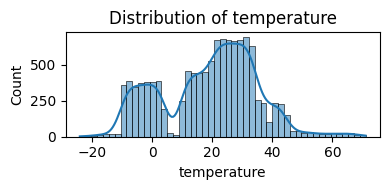

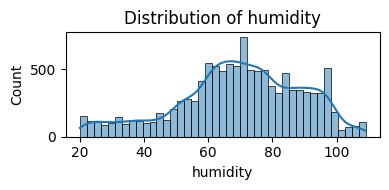

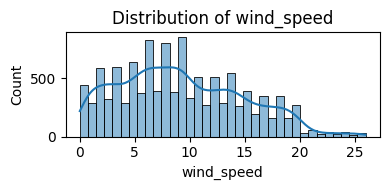

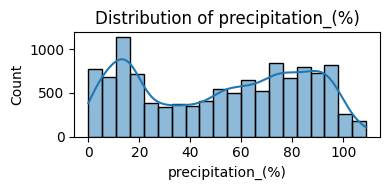

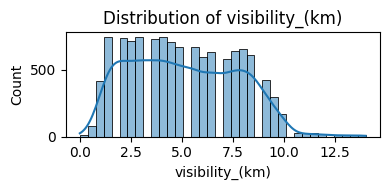

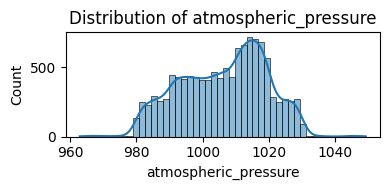

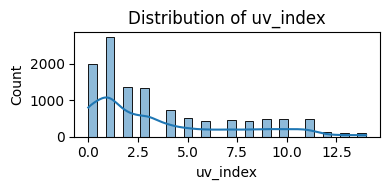

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(4, 2))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

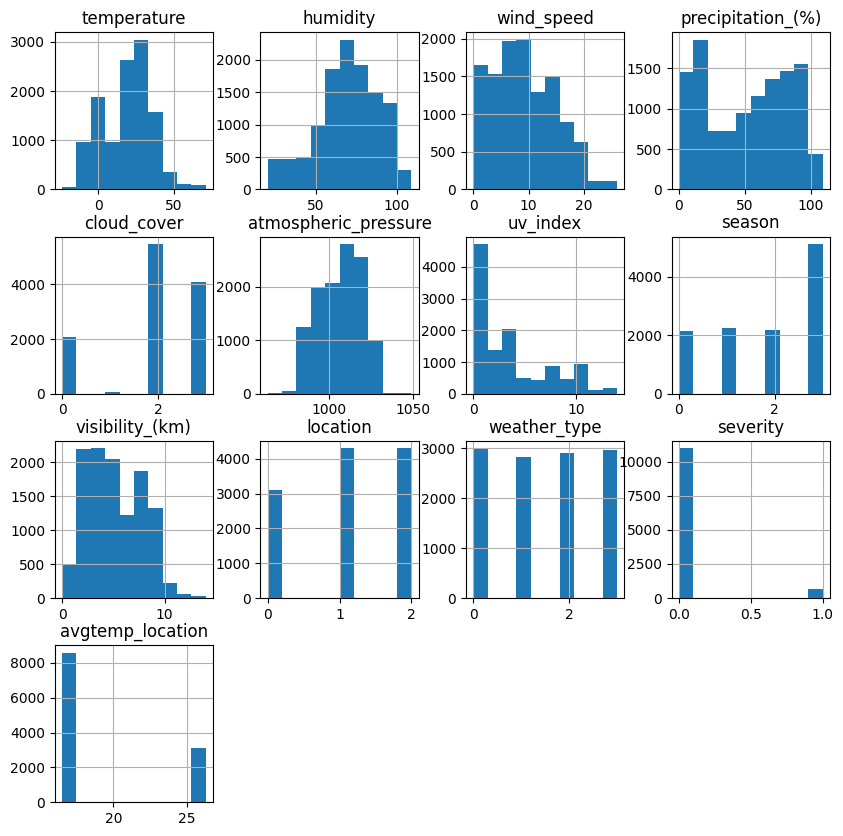

In [ ]:
data.hist(figsize=(10,10))
plt.show()

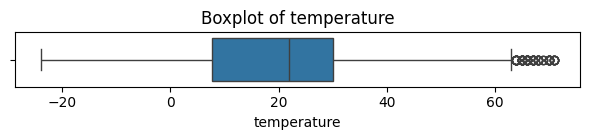

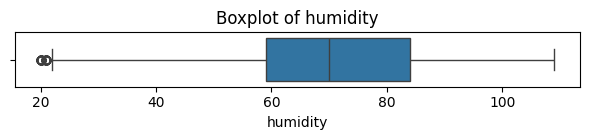

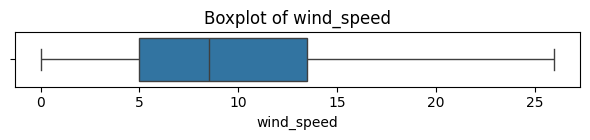

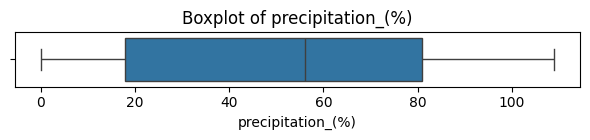

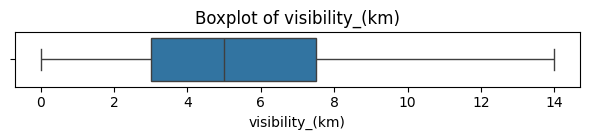

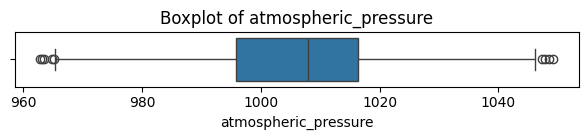

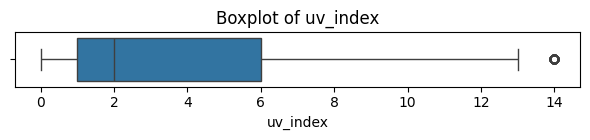

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

#Bivariate analysis

In [ ]:
px.scatter(data,x='temperature',y='season')

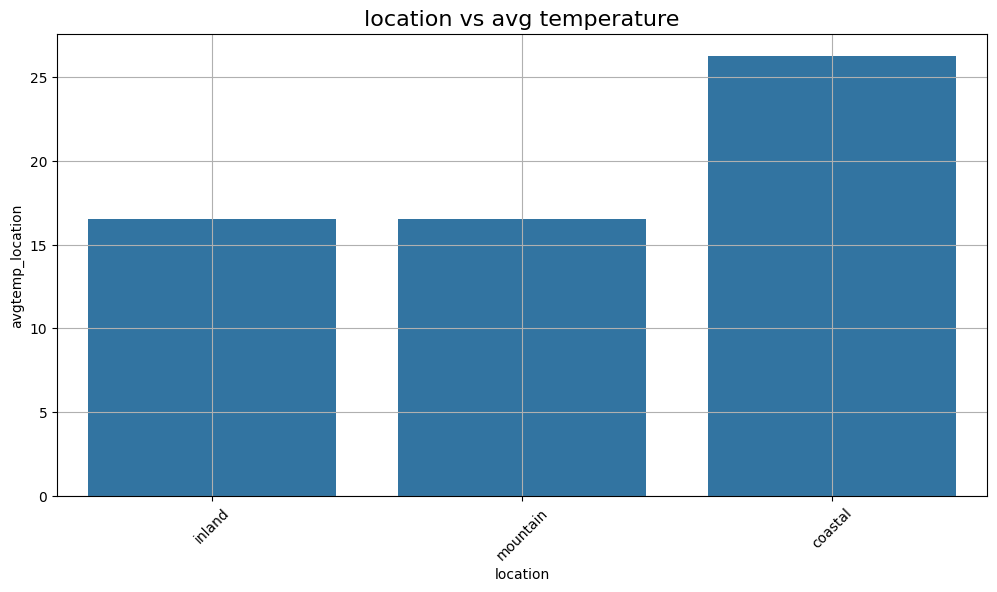

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=data, x='location',y='avgtemp_location')
plt.title('location vs avg temperature', fontsize=16)
plt.xlabel('location')
plt.ylabel('avgtemp_location')
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
# Enable grid for easier reading of the plot
plt.grid(True)
plt.show()

In [ ]:
data=pd.get_dummies(data,columns=['temp_category'],drop_first=True)

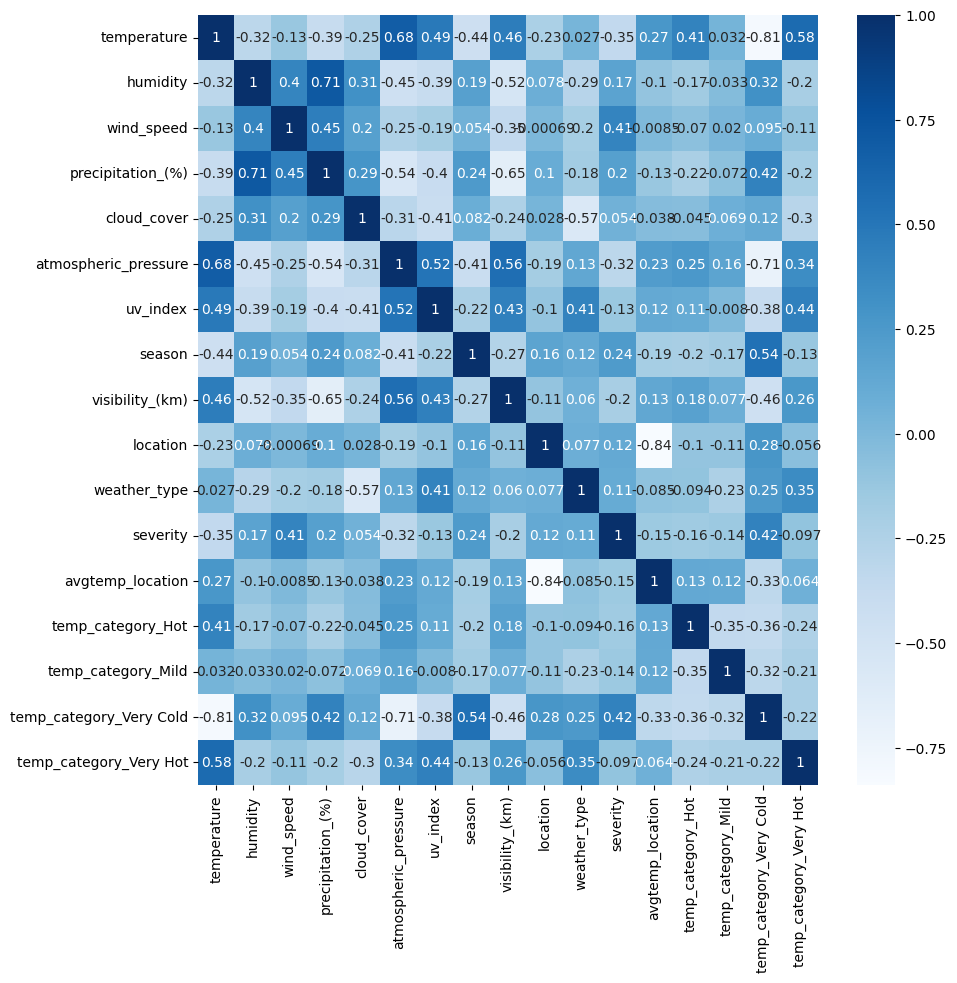

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True,cmap="Blues")
plt.show()

In [ ]:
fig = px.pie(data_frame=data,values='wind_speed', names='season', title='the wind speed by season')
fig.show()

#what is the most dangerous season

In [ ]:
temp_data = data.copy()
temp_data['season_label'] = label_encoders['season'].inverse_transform(temp_data['season'])
top_location = temp_data.groupby('season_label')['severity'].mean().sort_values(ascending=False)

In [ ]:
fig = px.bar(top_location, x=top_location.index, y='severity', title="most severity season", width=1000, height=500)
fig.show()

#What is the average temperature per location

In [ ]:
loc_data=data.copy()
loc_data['location_label'] = label_encoders['location'].inverse_transform(temp_data['location'])
avg_temp=loc_data.groupby('location_label')['temperature'].mean().sort_values(ascending=False)

In [ ]:
fig = px.bar(avg_temp, x=avg_temp.index, y='temperature', title="average temperature per location", width=1000, height=500)
fig.show()

In [ ]:
x = data.drop(columns=["weather_type", 'temp_category_Hot', 'temp_category_Mild' , 'temp_category_Very Cold' , 'temp_category_Very Hot','avgtemp_location', 'severity' ])
y = data['weather_type']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x.copy(),y.copy(),test_size=0.2,random_state=42)

In [ ]:
'''from sklearn.preprocessing import StandardScaler
scaled_numeric_data=['temperature','humidity','wind_speed','precipitation_(%)','visibility_(km)','atmospheric_pressure','uv_index']

scaler = StandardScaler()
x_train.loc[:,scaled_numeric_data] = scaler.fit_transform(x_train[scaled_numeric_data])
x_test.loc[:,scaled_numeric_data] = scaler.transform(x_test[scaled_numeric_data])'''

"from sklearn.preprocessing import StandardScaler\nscaled_numeric_data=['temperature','humidity','wind_speed','precipitation_(%)','visibility_(km)','atmospheric_pressure','uv_index']\n\nscaler = StandardScaler()\nx_train.loc[:,scaled_numeric_data] = scaler.fit_transform(x_train[scaled_numeric_data])\nx_test.loc[:,scaled_numeric_data] = scaler.transform(x_test[scaled_numeric_data])"

In [ ]:
x_train

,temperature,humidity,wind_speed,precipitation_(%),cloud_cover,atmospheric_pressure,uv_index,season,visibility_(km),location
1392,10.0,76.0,11.0,12.0,2,1003.75,2.0,2,7.5,1
201,-10.0,94.0,7.5,98.0,3,989.37,1.0,3,4.0,2
12873,17.0,54.0,0.5,47.0,3,1008.64,2.0,3,8.0,1
2967,-4.0,60.0,19.0,75.0,2,996.27,0.0,3,1.0,1
7799,21.0,74.0,14.0,79.0,3,1007.03,1.0,1,2.5,1
...,...,...,...,...,...,...,...,...,...,...
12748,-8.0,90.0,7.5,56.0,2,999.04,0.0,3,4.5,1
5799,32.0,42.0,6.0,11.0,3,1027.60,9.0,3,9.5,0
6017,11.0,64.0,9.0,22.0,2,1017.00,4.0,0,8.0,2
967,23.0,61.0,10.0,72.0,3,999.82,3.0,3,4.5,2


#Modeling

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_model=RandomForestClassifier(class_weight='balanced',random_state=42)
RF_model.fit(x_train,y_train)
y_pred=RF_model.predict(x_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print(f" The Accuracy : {accuracy * 100 :.2f}%")

 The Accuracy : 97.47%


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       636
           1       0.97      0.97      0.97       573
           2       0.99      0.98      0.99       553
           3       0.99      0.99      0.99       574

    accuracy                           0.97      2336
   macro avg       0.98      0.97      0.98      2336
weighted avg       0.97      0.97      0.97      2336



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(x_train, y_train)
best_rf_model = grid_rf.best_estimator_
y_pred = best_rf_model.predict(x_test)


# Best parameters and score
print("Best Random Forest Params:", grid_rf.best_params_)
print("Best Train Accuracy (RF): {:.2f}%".format(grid_rf.best_score_ * 100))

'from sklearn.ensemble import RandomForestClassifier\nfrom sklearn.model_selection import GridSearchCV\n\n# Define the model\nrf = RandomForestClassifier(random_state=42)\n\n# Define parameter grid\nparam_grid_rf = {\n    \'n_estimators\': [50, 100, 200],\n    \'max_depth\': [None, 10, 20],\n    \'min_samples_split\': [2, 5],\n    \'min_samples_leaf\': [1, 2]\n}\n\n# Grid search\ngrid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, scoring=\'accuracy\', n_jobs=-1)\ngrid_rf.fit(x_train, y_train)\nbest_rf_model = grid_rf.best_estimator_\ny_pred = best_rf_model.predict(x_test)\n\n\n# Best parameters and score\nprint("Best Random Forest Params:", grid_rf.best_params_)\nprint("Best Train Accuracy (RF): {:.2f}%".format(grid_rf.best_score_ * 100))'

In [ ]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = best_rf_model.predict(x_train)

# Predict on test data
y_test_pred = best_rf_model.predict(x_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("Train Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

'from sklearn.metrics import accuracy_score\n\n# Predict on training data\ny_train_pred = best_rf_model.predict(x_train)\n\n# Predict on test data\ny_test_pred = best_rf_model.predict(x_test)\n\n# Calculate accuracies\ntrain_accuracy = accuracy_score(y_train, y_train_pred)\ntest_accuracy = accuracy_score(y_test, y_test_pred)\n\n# Print results\nprint("Train Accuracy: {:.2f}%".format(train_accuracy * 100))\nprint("Test Accuracy: {:.2f}%".format(test_accuracy * 100))'

In [ ]:
import matplotlib.pyplot as plt

# Convert accuracies to percentage
train_acc_percent = train_accuracy * 100
test_acc_percent = test_accuracy * 100

# Plotting
labels = ['Train Accuracy', 'Test Accuracy']
values = [train_acc_percent, test_acc_percent]
colors = ['#4CAF50', '#2196F3']

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors)
plt.ylim(0, 105)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy (%)')

# Add value labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

'\nimport matplotlib.pyplot as plt\n\n# Convert accuracies to percentage\ntrain_acc_percent = train_accuracy * 100\ntest_acc_percent = test_accuracy * 100\n\n# Plotting\nlabels = [\'Train Accuracy\', \'Test Accuracy\']\nvalues = [train_acc_percent, test_acc_percent]\ncolors = [\'#4CAF50\', \'#2196F3\']\n\nplt.figure(figsize=(6, 4))\nplt.bar(labels, values, color=colors)\nplt.ylim(0, 105)\nplt.title(\'Train vs Test Accuracy\')\nplt.ylabel(\'Accuracy (%)\')\n\n# Add value labels on top of bars\nfor i, v in enumerate(values):\n    plt.text(i, v + 1, f"{v:.2f}%", ha=\'center\', fontweight=\'bold\')\n\nplt.show()\n'

In [ ]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=42)


model.fit(x_train, y_train)
y_pred = model.predict(x_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print(f" The Accuracy : {accuracy * 100 :.2f}%")

 The Accuracy : 92.04%


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89       636
           1       0.86      0.94      0.90       573
           2       0.98      0.98      0.98       553
           3       0.94      0.90      0.92       574

    accuracy                           0.92      2336
   macro avg       0.92      0.92      0.92      2336
weighted avg       0.92      0.92      0.92      2336



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Define the model
lr = LogisticRegression(max_iter=1000,random_state=42)

# Define parameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Grid search
grid_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr.fit(x_train, y_train)
best_lr_model = grid_lr.best_estimator_
y_pred = best_lr_model.predict(x_test)


# Best parameters and score
print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best Train Accuracy (LR): {:.2f}%".format(grid_lr.best_score_ * 100))

'\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import GridSearchCV\n\n# Define the model\nlr = LogisticRegression(max_iter=1000,random_state=42)\n\n# Define parameter grid\nparam_grid_lr = {\n    \'C\': [0.01, 0.1, 1, 10],\n    \'penalty\': [\'l1\', \'l2\'],\n    \'solver\': [\'liblinear\', \'saga\']\n}\n\n# Grid search\ngrid_lr = GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, scoring=\'accuracy\', n_jobs=-1)\ngrid_lr.fit(x_train, y_train)\nbest_lr_model = grid_lr.best_estimator_\ny_pred = best_lr_model.predict(x_test)\n\n\n# Best parameters and score\nprint("Best Logistic Regression Params:", grid_lr.best_params_)\nprint("Best Train Accuracy (LR): {:.2f}%".format(grid_lr.best_score_ * 100))\n'

In [ ]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = best_lr_model.predict(x_train)

# Predict on test data
y_test_pred = best_lr_model.predict(x_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("Train Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))


'\nfrom sklearn.metrics import accuracy_score\n\n# Predict on training data\ny_train_pred = best_lr_model.predict(x_train)\n\n# Predict on test data\ny_test_pred = best_lr_model.predict(x_test)\n\n# Calculate accuracies\ntrain_accuracy = accuracy_score(y_train, y_train_pred)\ntest_accuracy = accuracy_score(y_test, y_test_pred)\n\n# Print results\nprint("Train Accuracy: {:.2f}%".format(train_accuracy * 100))\nprint("Test Accuracy: {:.2f}%".format(test_accuracy * 100))\n'

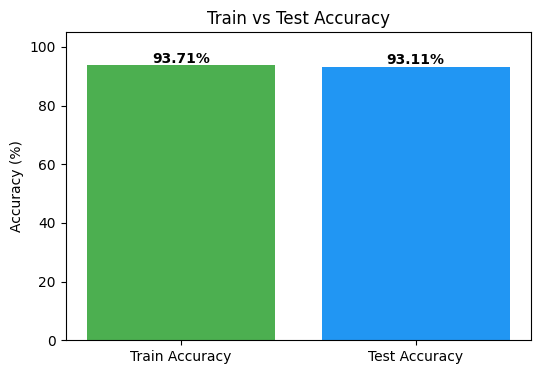

In [ ]:
import matplotlib.pyplot as plt

# Convert accuracies to percentage
train_acc_percent = train_accuracy * 100
test_acc_percent = test_accuracy * 100

# Plotting
labels = ['Train Accuracy', 'Test Accuracy']
values = [train_acc_percent, test_acc_percent]
colors = ['#4CAF50', '#2196F3']

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors)
plt.ylim(0, 105)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy (%)')

# Add value labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

model = xgb.XGBClassifier(
     learning_rate=0.2,
    max_depth=5,
    n_estimators=50,
    subsample=1,
    use_label_encoder=False,  # Avoids warning
    eval_metric='mlogloss',   # Required if you disable use_label_encoder
    random_state=42
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[15:17:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print(f" The Accuracy : {accuracy * 100 :.2f}%")

 The Accuracy : 97.09%


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Define the model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

# Define parameter grid
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
}

# Grid search
grid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(x_train, y_train)
best_xgb_model = grid_xgb.best_estimator_
y_pred = best_xgb_model.predict(x_test)

# Best parameters and score
print("Best XGBoost Params:", grid_xgb.best_params_)
print("Best Train Accuracy (XGB): {:.2f}%".format(grid_xgb.best_score_ * 100))


'\nimport xgboost as xgb\nfrom sklearn.model_selection import GridSearchCV\n\n# Define the model\nxgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric=\'mlogloss\')\n\n# Define parameter grid\nparam_grid_xgb = {\n    \'n_estimators\': [50, 100, 200],\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'subsample\': [0.7, 1],\n}\n\n# Grid search\ngrid_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb, cv=5, scoring=\'accuracy\', n_jobs=-1)\ngrid_xgb.fit(x_train, y_train)\nbest_xgb_model = grid_xgb.best_estimator_\ny_pred = best_xgb_model.predict(x_test)\n\n# Best parameters and score\nprint("Best XGBoost Params:", grid_xgb.best_params_)\nprint("Best Train Accuracy (XGB): {:.2f}%".format(grid_xgb.best_score_ * 100))\n'

In [ ]:
from sklearn.metrics import accuracy_score

# Predict on training data
y_train_pred = best_xgb_model.predict(x_train)

# Predict on test data
y_test_pred = best_xgb_model.predict(x_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print("Train Accuracy: {:.2f}%".format(train_accuracy * 100))
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))


'\nfrom sklearn.metrics import accuracy_score\n\n# Predict on training data\ny_train_pred = best_xgb_model.predict(x_train)\n\n# Predict on test data\ny_test_pred = best_xgb_model.predict(x_test)\n\n# Calculate accuracy\ntrain_accuracy = accuracy_score(y_train, y_train_pred)\ntest_accuracy = accuracy_score(y_test, y_test_pred)\n\n# Print results\nprint("Train Accuracy: {:.2f}%".format(train_accuracy * 100))\nprint("Test Accuracy: {:.2f}%".format(test_accuracy * 100))\n'

In [ ]:
import matplotlib.pyplot as plt

# Convert accuracies to percentage
train_acc_percent = train_accuracy * 100
test_acc_percent = test_accuracy * 100

# Plotting
labels = ['Train Accuracy', 'Test Accuracy']
values = [train_acc_percent, test_acc_percent]
colors = ['#4CAF50', '#2196F3']

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=colors)
plt.ylim(0, 105)
plt.title('Train vs Test Accuracy')
plt.ylabel('Accuracy (%)')

# Add value labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()


'\nimport matplotlib.pyplot as plt\n\n# Convert accuracies to percentage\ntrain_acc_percent = train_accuracy * 100\ntest_acc_percent = test_accuracy * 100\n\n# Plotting\nlabels = [\'Train Accuracy\', \'Test Accuracy\']\nvalues = [train_acc_percent, test_acc_percent]\ncolors = [\'#4CAF50\', \'#2196F3\']\n\nplt.figure(figsize=(6, 4))\nplt.bar(labels, values, color=colors)\nplt.ylim(0, 105)\nplt.title(\'Train vs Test Accuracy\')\nplt.ylabel(\'Accuracy (%)\')\n\n# Add value labels on top of bars\nfor i, v in enumerate(values):\n    plt.text(i, v + 1, f"{v:.2f}%", ha=\'center\', fontweight=\'bold\')\n\nplt.show()\n\n'

In [ ]:
important = model.feature_importances_
column = x.columns

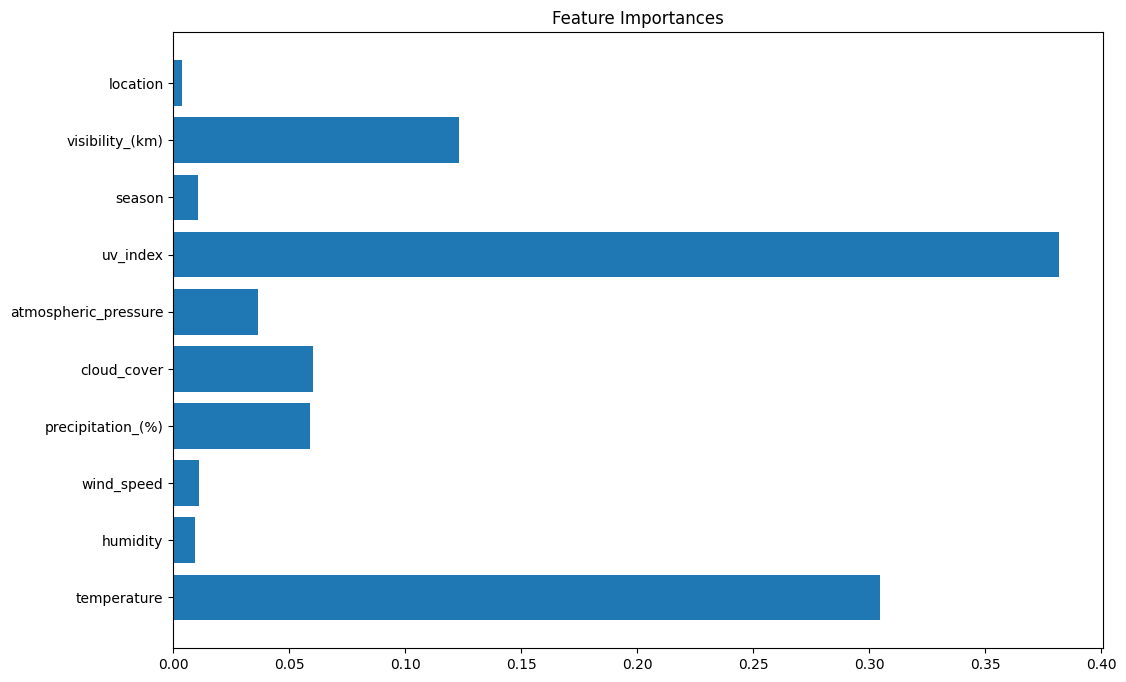

In [ ]:
plt.figure(figsize=(12, 8))
plt.barh(column, important)
plt.title('Feature Importances')
plt.show()

In [ ]:
'''import joblib

# Save the trained model
joblib.dump(RF_model, 'rf_weather_model.pkl')

'''

"\nimport joblib\n\n# Save the trained model\njoblib.dump(RF_model, 'rf_weather_model.pkl')\n"

In [ ]:
x_train

,temperature,humidity,wind_speed,precipitation_(%),cloud_cover,atmospheric_pressure,uv_index,season,visibility_(km),location
1392,10.0,76.0,11.0,12.0,2,1003.75,2.0,2,7.5,1
201,-10.0,94.0,7.5,98.0,3,989.37,1.0,3,4.0,2
12873,17.0,54.0,0.5,47.0,3,1008.64,2.0,3,8.0,1
2967,-4.0,60.0,19.0,75.0,2,996.27,0.0,3,1.0,1
7799,21.0,74.0,14.0,79.0,3,1007.03,1.0,1,2.5,1
...,...,...,...,...,...,...,...,...,...,...
12748,-8.0,90.0,7.5,56.0,2,999.04,0.0,3,4.5,1
5799,32.0,42.0,6.0,11.0,3,1027.60,9.0,3,9.5,0
6017,11.0,64.0,9.0,22.0,2,1017.00,4.0,0,8.0,2
967,23.0,61.0,10.0,72.0,3,999.82,3.0,3,4.5,2


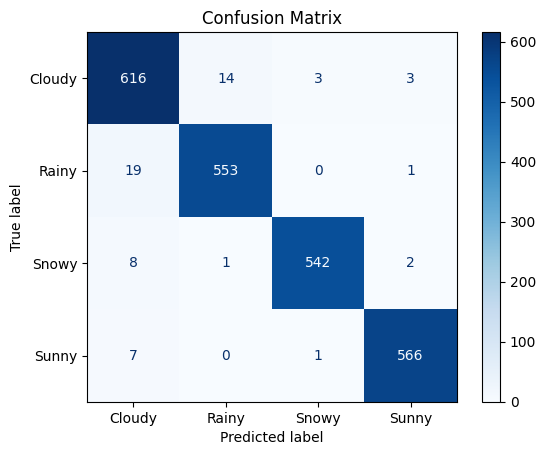

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Predict on test data
y_pred = RF_model.predict(x_test)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Optional: class names if available
class_names = ['Cloudy', 'Rainy', 'Snowy', 'Sunny']  # Update this based on your encoding

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()


#Deployment

In [ ]:
import gradio as gr
import joblib
import numpy as np

# Load model only (scaler removed)
rf_model = joblib.load("rf_weather_model.pkl")

weather_type_mapping = {
    0: "Cloudy",
    1: "Rainy",
    2: "Snow",
    3: "Sunny"
}

def predict_weather_type(temperature, humidity, wind_speed, precipitation_percent,
                         cloud_cover, atmospheric_pressure, uv_index,
                         season, visibility_km, location):
    try:
        # 1. Prepare input directly without scaling
        final_input = np.array([[temperature, humidity, wind_speed, precipitation_percent,
                                 cloud_cover, atmospheric_pressure, uv_index,
                                 season, visibility_km, location]])

        # 2. Predict
        encoded_prediction = RF_model.predict(final_input)[0]
        readable_prediction = weather_type_mapping.get(encoded_prediction, "Unknown")

        # 3. Return prediction + debug info
        input_info = f"Input to model: {final_input}"
        return f"Predicted Weather Type: {readable_prediction} ({encoded_prediction})", input_info

    except Exception as e:
        return f"Error: {str(e)}", ""

# Gradio Interface
interface = gr.Interface(
    fn=predict_weather_type,
    inputs=[
        gr.Number(label="Temperature (°C)"),
        gr.Number(label="Humidity (%)"),
        gr.Number(label="Wind Speed (km/h)"),
        gr.Number(label="Precipitation (%)"),
        gr.Number(label="Cloud Cover (encoded)"),
        gr.Number(label="Atmospheric Pressure (hPa)"),
        gr.Number(label="UV Index"),
        gr.Number(label="Season (encoded)"),
        gr.Number(label="Visibility (km)"),
        gr.Number(label="Location (encoded)")
    ],
    outputs=[
        gr.Text(label="Prediction"),
        gr.Text(label="Debug Info (Model Input)")
    ],
    title="🌤️ Weather Type Predictor",
    description="Enter weather data to predict the weather type using a trained model."
)

interface.launch(debug=True)


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a99322cf78dd4124eb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a99322cf78dd4124eb.gradio.live
